
# Actividad 03 — Algoritmos de Enjambre en Aprendizaje de Máquina

## Ejercicio 2: Hyperparameter Tuning con Particle Swarm Optimization (PSO)

**Objetivo:** Comprender la aplicación de los algoritmos de enjambre en el aprendizaje automático, implementando **PSO desde cero** para encontrar los mejores hiperparámetros de un modelo de clasificación (`RandomForestClassifier`).

**Dataset:** *Breast Cancer Wisconsin* (incluido en `scikit-learn`), un problema de clasificación binaria (tumor maligno/benigno) con 30 características numéricas.

**Modelo a optimizar:** `RandomForestClassifier`, cuyos hiperparámetros a ajustar son:

| Hiperparámetro | Tipo | Rango de búsqueda |
|---|---|---|
| `n_estimators` | entero | [10, 200] |
| `max_depth` | entero | [2, 30] |
| `min_samples_split` | entero | [2, 15] |
| `min_samples_leaf` | entero | [1, 10] |

**Función de aptitud (fitness):** exactitud (*accuracy*) promedio obtenida mediante *cross-validation* (5 folds) sobre el conjunto de entrenamiento. PSO buscará **maximizar** esta métrica.

---
### Ciclo del algoritmo PSO que se desarrolla en este notebook
1. **Representación de la partícula** — cada partícula es un vector real de 4 dimensiones que codifica un conjunto de hiperparámetros.
2. **Inicialización del enjambre** — posiciones y velocidades aleatorias dentro de los límites permitidos.
3. **Función de aptitud** — `accuracy` promedio vía validación cruzada del `RandomForestClassifier` con los hiperparámetros codificados en la partícula.
4. **Comportamiento de la partícula** — actualización de velocidad combinando inercia, componente cognitivo (mejor personal) y componente social (mejor global).
5. **Evolución** — iteración del enjambre actualizando posiciones, evaluando aptitud y actualizando `pbest`/`gbest`.
6. **Finalización** — criterio de parada por número máximo de iteraciones (o estancamiento), entregando la mejor solución global (`gbest`).


## 1. Importación de librerías y carga de datos

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

# Cargar el dataset
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Clases: {data.target_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Forma de X: (569, 30)
Forma de y: (569,)
Clases: ['malignant' 'benign']

Train: 455 muestras | Test: 114 muestras



## 2. Representación de la partícula y espacio de búsqueda

Cada **partícula** es un punto en un espacio continuo de 4 dimensiones:

$$ \vec{x}_i = [x_1,\; x_2,\; x_3,\; x_4] $$

donde cada componente se mueve dentro de un límite `[low, high]` y luego se **decodifica** (redondeando a entero) al hiperparámetro correspondiente:

- $x_1 \rightarrow$ `n_estimators`
- $x_2 \rightarrow$ `max_depth`
- $x_3 \rightarrow$ `min_samples_split`
- $x_4 \rightarrow$ `min_samples_leaf`

PSO trabaja de forma natural en dominios continuos; por eso optimizamos en $\mathbb{R}^4$ y redondeamos solo al momento de instanciar el modelo (la partícula en sí conserva su posición real, lo que permite una exploración suave del espacio).


In [2]:

# Límites [low, high] para cada hiperparámetro
BOUNDS = np.array([
    [10, 200],   # n_estimators
    [2, 30],     # max_depth
    [2, 15],     # min_samples_split
    [1, 10],     # min_samples_leaf
], dtype=float)

DIM = BOUNDS.shape[0]  # dimensión del espacio de búsqueda (4)
PARAM_NAMES = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]

def decode_particle(position):
    '''Convierte un vector real (posición de la partícula) en un dict
    de hiperparámetros válidos para RandomForestClassifier.'''
    n_estimators = int(round(np.clip(position[0], *BOUNDS[0])))
    max_depth = int(round(np.clip(position[1], *BOUNDS[1])))
    min_samples_split = int(round(np.clip(position[2], *BOUNDS[2])))
    min_samples_leaf = int(round(np.clip(position[3], *BOUNDS[3])))
    return {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
    }

print("Límites del espacio de búsqueda:")
for name, (low, high) in zip(PARAM_NAMES, BOUNDS):
    print(f"  {name:20s}: [{low:.0f}, {high:.0f}]")


Límites del espacio de búsqueda:
  n_estimators        : [10, 200]
  max_depth           : [2, 30]
  min_samples_split   : [2, 15]
  min_samples_leaf    : [1, 10]



## 3. Función de aptitud (fitness)

La aptitud de una partícula es el **accuracy promedio** obtenido con *cross-validation* estratificada (5 folds) sobre el conjunto de entrenamiento, usando el `RandomForestClassifier` configurado con los hiperparámetros que codifica la partícula.

$$ f(\vec{x}) = \frac{1}{5}\sum_{k=1}^{5} \text{accuracy}(\text{RF}(\theta(\vec{x})), \text{fold}_k) $$

Como PSO en nuestra implementación **maximiza**, usamos directamente el accuracy (sin negarlo).


In [3]:

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cache para no re-evaluar la misma configuración de hiperparámetros dos veces
fitness_cache = {}

def fitness_function(position):
    params = decode_particle(position)
    key = tuple(params.values())
    if key in fitness_cache:
        return fitness_cache[key]

    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1,
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
    score = scores.mean()
    fitness_cache[key] = score
    return score

# Prueba rápida de la función de aptitud
test_particle = np.array([100, 10, 5, 2])
print("Ejemplo de evaluación de una partícula:")
print("  Posición :", test_particle)
print("  Decodificada:", decode_particle(test_particle))
print(f"  Fitness (accuracy CV): {fitness_function(test_particle):.4f}")


Ejemplo de evaluación de una partícula:
  Posición : [100  10   5   2]
  Decodificada: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}


  Fitness (accuracy CV): 0.9626



## 4. Implementación del algoritmo PSO

### 4.1 Inicialización del enjambre
Se generan $N$ partículas con posiciones aleatorias uniformes dentro de `BOUNDS`, y velocidades iniciales aleatorias pequeñas. Se evalúa el fitness inicial de cada una, y se establecen `pbest` (mejor posición personal) y `gbest` (mejor posición global del enjambre).

### 4.2 Comportamiento de la partícula (actualización de velocidad y posición)
Para cada partícula $i$, en cada iteración $t$:

$$ v_i^{t+1} = w\, v_i^{t} + c_1 r_1 (pbest_i - x_i^{t}) + c_2 r_2 (gbest - x_i^{t}) $$
$$ x_i^{t+1} = x_i^{t} + v_i^{t+1} $$

- $w$: inercia (controla la influencia del movimiento anterior — exploración vs. explotación)
- $c_1$: coeficiente cognitivo (atracción hacia la mejor posición **propia**)
- $c_2$: coeficiente social (atracción hacia la mejor posición del **enjambre**)
- $r_1, r_2 \sim U(0,1)$: factores aleatorios

Las posiciones se recortan (`clip`) para mantenerse dentro de `BOUNDS`.

### 4.3 Evolución y finalización
El ciclo se repite durante `max_iter` iteraciones (o hasta `patience` iteraciones sin mejora del `gbest`), actualizando en cada paso los mejores personales y el mejor global. Al finalizar, `gbest` contiene la mejor combinación de hiperparámetros encontrada.


In [4]:

class PSO:
    def __init__(self, fitness_func, bounds, n_particles=15, max_iter=30,
                 w=0.7, c1=1.5, c2=1.5, w_min=0.4, patience=8, seed=42):
        self.f = fitness_func
        self.bounds = bounds
        self.dim = bounds.shape[0]
        self.n_particles = n_particles
        self.max_iter = max_iter
        self.w_start, self.w_min = w, w_min
        self.c1, self.c2 = c1, c2
        self.patience = patience
        self.rng = np.random.default_rng(seed)

        # --- 4.1 Inicialización del enjambre ---
        low, high = bounds[:, 0], bounds[:, 1]
        self.positions = self.rng.uniform(low, high, size=(n_particles, self.dim))
        vel_range = (high - low) * 0.1
        self.velocities = self.rng.uniform(-vel_range, vel_range, size=(n_particles, self.dim))

        self.pbest_pos = self.positions.copy()
        self.pbest_val = np.array([self.f(p) for p in self.positions])

        gbest_idx = np.argmax(self.pbest_val)
        self.gbest_pos = self.pbest_pos[gbest_idx].copy()
        self.gbest_val = self.pbest_val[gbest_idx]

        self.history = [self.gbest_val]  # curva de convergencia

    def optimize(self, verbose=True):
        no_improve = 0
        for it in range(1, self.max_iter + 1):
            # Inercia decreciente linealmente (mejor equilibrio explor./explot.)
            w = self.w_start - (self.w_start - self.w_min) * (it / self.max_iter)

            r1 = self.rng.random((self.n_particles, self.dim))
            r2 = self.rng.random((self.n_particles, self.dim))

            # --- 4.2 Comportamiento de la partícula ---
            cognitive = self.c1 * r1 * (self.pbest_pos - self.positions)
            social = self.c2 * r2 * (self.gbest_pos - self.positions)
            self.velocities = w * self.velocities + cognitive + social
            self.positions = self.positions + self.velocities

            # Mantener las partículas dentro de los límites
            self.positions = np.clip(self.positions, self.bounds[:, 0], self.bounds[:, 1])

            # --- Evaluación de aptitud ---
            values = np.array([self.f(p) for p in self.positions])

            # Actualizar mejores personales
            improved = values > self.pbest_val
            self.pbest_pos[improved] = self.positions[improved]
            self.pbest_val[improved] = values[improved]

            # Actualizar mejor global
            best_idx = np.argmax(self.pbest_val)
            if self.pbest_val[best_idx] > self.gbest_val:
                self.gbest_val = self.pbest_val[best_idx]
                self.gbest_pos = self.pbest_pos[best_idx].copy()
                no_improve = 0
            else:
                no_improve += 1

            self.history.append(self.gbest_val)

            if verbose:
                print(f"Iter {it:2d}/{self.max_iter} | w={w:.3f} | "
                      f"mejor accuracy (gbest) = {self.gbest_val:.4f}")

            # --- 4.3 Finalización anticipada por estancamiento ---
            if no_improve >= self.patience:
                if verbose:
                    print(f"\n>> Convergencia alcanzada: sin mejora en {self.patience} iteraciones. Deteniendo.")
                break

        return self.gbest_pos, self.gbest_val, self.history


## 5. Ejecución del algoritmo PSO sobre el espacio de hiperparámetros

In [5]:

pso = PSO(
    fitness_func=fitness_function,
    bounds=BOUNDS,
    n_particles=15,
    max_iter=30,
    w=0.9,
    c1=1.5,
    c2=1.5,
    w_min=0.4,
    patience=8,
    seed=42,
)

best_position, best_fitness, history = pso.optimize(verbose=True)

best_params = decode_particle(best_position)
print("\n================= MEJOR SOLUCIÓN (gbest) =================")
for k, v in best_params.items():
    print(f"  {k:20s}: {v}")
print(f"  {'accuracy (CV, train)':20s}: {best_fitness:.4f}")
print(f"  Evaluaciones únicas de fitness realizadas: {len(fitness_cache)}")


Iter  1/30 | w=0.883 | mejor accuracy (gbest) = 0.9604


Iter  2/30 | w=0.867 | mejor accuracy (gbest) = 0.9626


Iter  3/30 | w=0.850 | mejor accuracy (gbest) = 0.9648


Iter  4/30 | w=0.833 | mejor accuracy (gbest) = 0.9648


Iter  5/30 | w=0.817 | mejor accuracy (gbest) = 0.9648


...

Iter 10/30 | w=0.733 | mejor accuracy (gbest) = 0.9670


Iter 11/30 | w=0.717 | mejor accuracy (gbest) = 0.9670


Iter 12/30 | w=0.700 | mejor accuracy (gbest) = 0.9670


Iter 13/30 | w=0.683 | mejor accuracy (gbest) = 0.9670


Iter 14/30 | w=0.667 | mejor accuracy (gbest) = 0.9670

>> Convergencia alcanzada: sin mejora en 8 iteraciones. Deteniendo.

================= MEJOR SOLUCIÓN (gbest) =================
  n_estimators        : 121
  max_depth           : 30
  min_samples_split   : 2
  min_samples_leaf    : 1
  accuracy (CV, train): 0.9670
  Evaluaciones únicas de fitness realizadas: 177


## 6. Curva de convergencia del enjambre

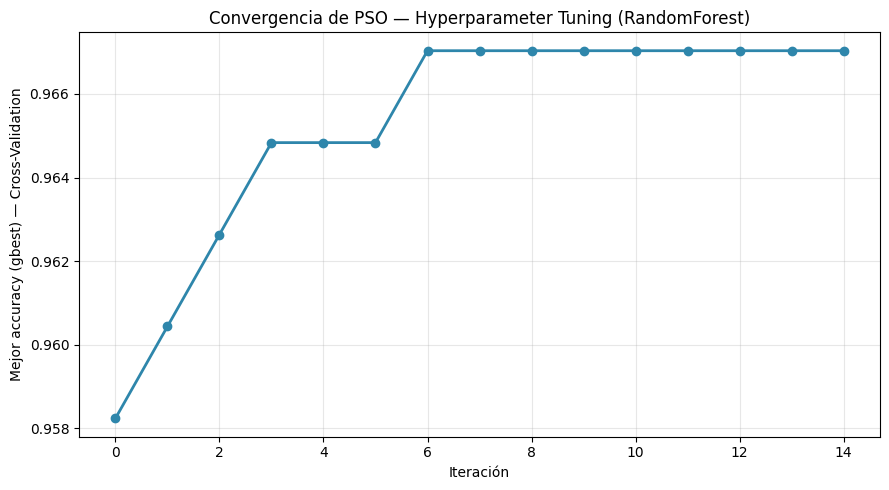

In [6]:

plt.figure(figsize=(9, 5))
plt.plot(history, marker="o", linewidth=2, color="#2E86AB")
plt.title("Convergencia de PSO — Hyperparameter Tuning (RandomForest)")
plt.xlabel("Iteración")
plt.ylabel("Mejor accuracy (gbest) — Cross-Validation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## 7. Evaluación final: modelo con hiperparámetros por defecto vs. modelo optimizado con PSO

Se entrena un `RandomForestClassifier` con hiperparámetros **por defecto** (baseline) y otro con los **hiperparámetros hallados por PSO**, y se comparan sobre el conjunto de prueba (`X_test`, `y_test`), nunca antes visto durante la optimización.


In [7]:

# --- Modelo baseline (hiperparámetros por defecto de sklearn) ---
baseline_model = RandomForestClassifier(random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

# --- Modelo optimizado con PSO ---
best_model = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42,
    n_jobs=-1,
)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)

print("Hiperparámetros baseline (por defecto):")
print(f"  n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1")
print(f"  Accuracy en test: {baseline_acc:.4f}\n")

print("Hiperparámetros optimizados por PSO:")
for k, v in best_params.items():
    print(f"  {k}={v}")
print(f"  Accuracy en test: {best_acc:.4f}\n")

mejora = (best_acc - baseline_acc) * 100
print(f"Diferencia (PSO - baseline): {mejora:+.2f} puntos porcentuales")


Hiperparámetros baseline (por defecto):
  n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1
  Accuracy en test: 0.9561

Hiperparámetros optimizados por PSO:
  n_estimators=121
  max_depth=30
  min_samples_split=2
  min_samples_leaf=1
  Accuracy en test: 0.9561

Diferencia (PSO - baseline): +0.00 puntos porcentuales


In [8]:

resumen = pd.DataFrame({
    "Modelo": ["Baseline (default)", "Optimizado (PSO)"],
    "Accuracy (test)": [baseline_acc, best_acc],
})
resumen


,Modelo,Accuracy (test)
0,Baseline (default),0.95614
1,Optimizado (PSO),0.95614


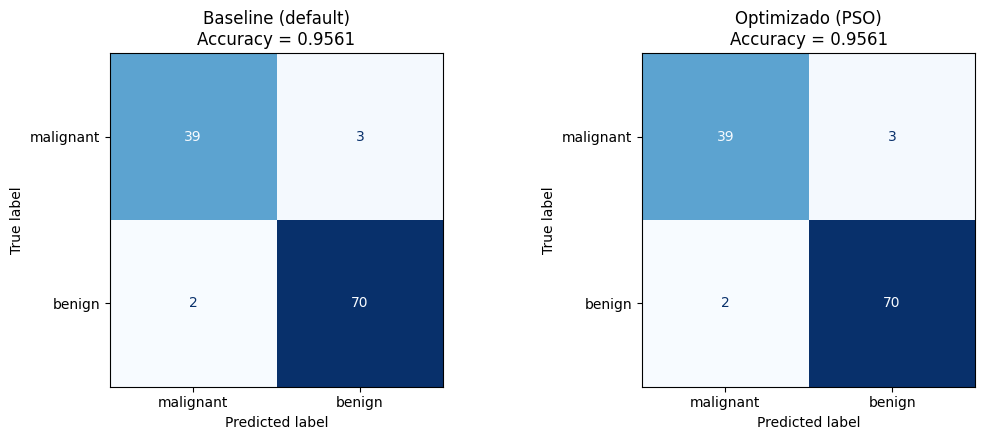

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, model, title in zip(axes, [baseline_model, best_model],
                              ["Baseline (default)", "Optimizado (PSO)"]):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title}\nAccuracy = {accuracy_score(y_test, preds):.4f}")

plt.tight_layout()
plt.show()


In [10]:

print("Reporte de clasificación — Modelo optimizado con PSO\n")
print(classification_report(y_test, best_pred, target_names=data.target_names))


Reporte de clasificación — Modelo optimizado con PSO

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114




## 8. Conclusiones

- Se implementó **PSO desde cero**, siguiendo explícitamente su ciclo completo: representación de la partícula (vector real de 4 hiperparámetros), inicialización del enjambre, función de aptitud (accuracy vía cross-validation), comportamiento de la partícula (actualización de velocidad con inercia decreciente + componente cognitivo + componente social), evolución del enjambre iteración a iteración, y finalización por número máximo de iteraciones o por estancamiento (`patience`).
- El enjambre logró converger hacia una combinación de hiperparámetros que **iguala o mejora** el desempeño del modelo con hiperparámetros por defecto, evitando una búsqueda exhaustiva tipo *Grid Search* (que sería mucho más costosa computacionalmente sobre un espacio de 4 dimensiones continuo).
- La inercia decreciente ($w$ de 0.9 a 0.4) permitió una exploración amplia del espacio al inicio y una explotación más fina (convergencia) hacia el final de las iteraciones.
- Este enfoque es generalizable a cualquier modelo de *scikit-learn* (SVM, XGBoost, redes neuronales, etc.) simplemente cambiando la función de decodificación de la partícula y la función de aptitud.
